# Portfolio Replica Strategy - Complete Data Analysis


This notebook builds the empirical foundation for a **portfolio replication** project. Before estimating linear, penalized, or dynamic models, we inspect the dataset, returns, drawdowns, correlations, correlation stability, and the economic meaning of the instruments.

The goal is to understand whether a liquid futures universe can replicate a target index built from hedge fund, global equity, and global bond exposures.


## 1. Setup

The dataset contains weekly index and futures price series. We work with both price levels, which are useful for visualizing historical performance, and percentage returns, which are required for statistical analysis and replication models.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (13, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ANNUAL_FACTOR = 52

try:
    PROJECT_DIR = Path.cwd()
except PermissionError:
    PROJECT_DIR = Path.home() 

FILE_PATH = PROJECT_DIR / "Dataset3_PortfolioReplicaStrategy.xlsx"
if not FILE_PATH.exists():
    FILE_PATH = "Dataset3_PortfolioReplicaStrategy.xlsx"


## 2. Investment Universe and Economic Meaning

The dataset combines three groups of instruments:

**Target / benchmark indices**

- `HFRXGL`: global hedge fund index. This is the hardest block to replicate because it reflects active strategies, changing exposures, market timing, and potentially non-linear sources of alpha.
- `MXWO`: MSCI World, a proxy for developed-market global equities.
- `MXWD`: broad global equity proxy included in the dataset; useful as an additional equity benchmark.
- `LEGATRUU`: Bloomberg/Barclays Global Aggregate bond index, a proxy for global investment-grade fixed income.

**Bond and rates futures**

- `RX1`, `DU1`: German government bond futures, broadly linked to the European risk-free curve.
- `TY1`, `TU2`: US Treasury futures, capturing intermediate/long and short-rate exposures.

**Equity, commodity, and other market futures**

- `ES1`, `NQ1`: S&P 500 and Nasdaq futures, representing the core US equity beta.
- `VG1`, `TP1`, `LLL1`: non-US/regional equity futures, useful for geographic diversification.
- `GC1`: gold, often related to real rates, inflation expectations, and safe-haven demand.
- `CO1`: crude oil, sensitive to the global cycle, supply shocks, and growth expectations.

Economically, a robust replica should combine **equity beta**, **bond duration**, **commodity exposure**, and defensive components. The main difficulty is that correlations are not stable through time.


## 3. Dataset Loading and Quality Checks

We first check the sample period, frequency, duplicated dates, missing values, and column structure. A clean weekly dataset is essential: missing observations or irregular dates can distort returns and rolling correlations.


In [2]:
data_raw = pd.read_excel(FILE_PATH, sheet_name=0, header=0)
data_raw = data_raw.rename(columns={data_raw.columns[0]: "Date"})
data_raw["Date"] = pd.to_datetime(data_raw["Date"])
data = data_raw.set_index("Date").sort_index()

index_cols = ["MXWO", "MXWD", "LEGATRUU", "HFRXGL"]
futures_cols = ["RX1", "TY1", "GC1", "CO1", "ES1", "VG1", "NQ1", "LLL1", "TP1", "DU1", "TU2"]

quality_summary = pd.DataFrame({
    "Observations": data.count(),
    "Missing": data.isna().sum(),
    "Missing %": data.isna().mean() * 100,
    "Min": data.min(),
    "Max": data.max(),
})

print(f"Loaded file: {FILE_PATH}")
print(f"Sample period: {data.index.min().date()} -> {data.index.max().date()}")
print(f"Number of observations: {len(data):,}")
print(f"Duplicated dates: {data.index.duplicated().sum()}")
display(quality_summary)
display(data.head())


Loaded file: /Users/nicolzanotti/Desktop/Fintech/BusinessCase3/Dataset3_PortfolioReplicaStrategy.xlsx
Sample period: 2007-10-23 -> 2021-04-20
Number of observations: 705
Duplicated dates: 0


,Observations,Missing,Missing %,Min,Max
MXWO,705,0,0.0000,705.3500,"2,944.0500"
MXWD,705,0,0.0000,176.1000,702.9900
LEGATRUU,705,0,0.0000,342.2471,559.3117
HFRXGL,705,0,0.0000,"1,021.4000","1,415.1100"
RX1,705,0,0.0000,110.2000,179.3200
TY1,705,0,0.0000,110.5156,140.3281
GC1,705,0,0.0000,732.7000,"2,001.2000"
CO1,705,0,0.0000,19.3300,140.6700
ES1,705,0,0.0000,689.5000,"4,132.8000"
VG1,705,0,0.0000,"1,873.0000","4,476.0000"


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Date,,,,,,,,,,,,,,,
2007-10-23,"1,633.4400",414.1400,350.2138,"1,343.6300",113.7000,110.5156,759.0000,82.8500,"1,525.5000","4,393.0000","2,212.0000","1,287.0000","1,570.5000",103.3850,103.7188
2007-10-30,"1,663.8900",423.2600,352.5413,"1,356.5300",113.7900,110.6562,787.8000,87.4400,"1,536.0000","4,476.0000","2,217.7500","1,323.9000","1,610.5000",103.4100,103.8125
2007-11-06,"1,651.5900",419.5100,354.1758,"1,360.2000",113.7900,110.8750,823.4000,93.2600,"1,525.0000","4,425.0000","2,233.5000","1,320.0000","1,575.5000",103.4100,104.0469
2007-11-13,"1,601.8100",405.9800,357.2217,"1,347.1600",114.3500,111.7188,799.0000,88.8300,"1,483.2500","4,323.0000","2,066.7500","1,271.0000","1,440.5000",103.5950,104.3047
2007-11-20,"1,570.7400",398.5400,359.4446,"1,335.2100",114.7200,113.1562,791.4000,95.4900,"1,446.0000","4,296.0000","2,035.5000","1,225.2000","1,472.5000",103.8000,104.9453


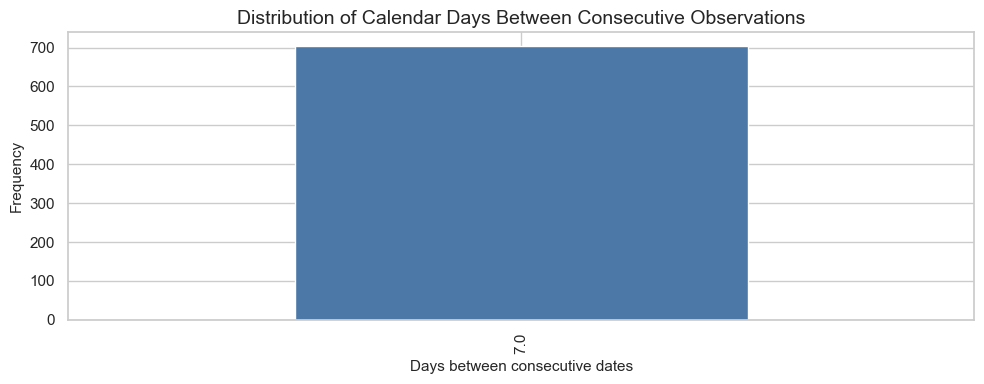

,Gap in days
count,704.0000
mean,7.0000
std,0.0000
min,7.0000
25%,7.0000
50%,7.0000
75%,7.0000
max,7.0000


In [3]:
date_gaps = data.index.to_series().diff().dt.days.dropna()

fig, ax = plt.subplots(figsize=(10, 4))
date_gaps.value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title("Distribution of Calendar Days Between Consecutive Observations")
ax.set_xlabel("Days between consecutive dates")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

display(date_gaps.describe().to_frame("Gap in days"))


## 4. Historical Performance in Price Levels

Price levels are not stationary, but they help explain the economic history of the sample: the Global Financial Crisis, the Euro sovereign debt crisis, the quantitative easing years, the Covid sell-off, and the 2020-2021 recovery.


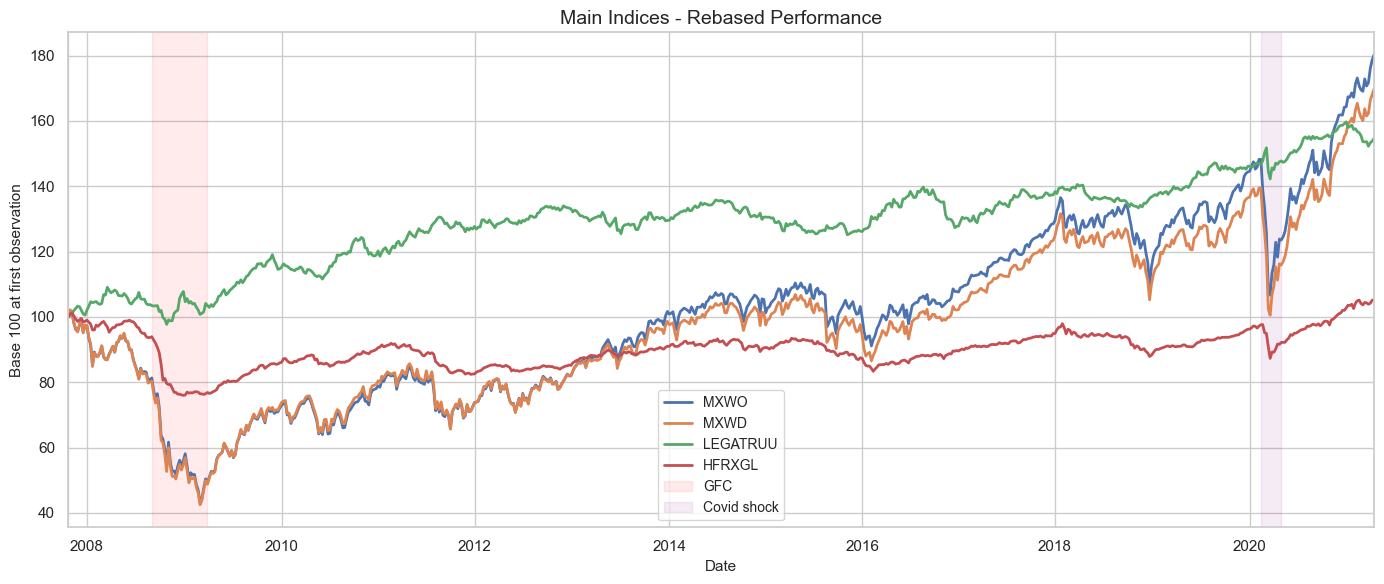

In [4]:
prices_base100 = data / data.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 6))
prices_base100[index_cols].plot(ax=ax, linewidth=2)
ax.set_title("Main Indices - Rebased Performance")
ax.set_ylabel("Base 100 at first observation")
ax.axvspan(pd.Timestamp("2008-09-01"), pd.Timestamp("2009-03-31"), color="red", alpha=0.08, label="GFC")
ax.axvspan(pd.Timestamp("2020-02-15"), pd.Timestamp("2020-04-30"), color="purple", alpha=0.08, label="Covid shock")
ax.legend()
plt.tight_layout()
plt.show()


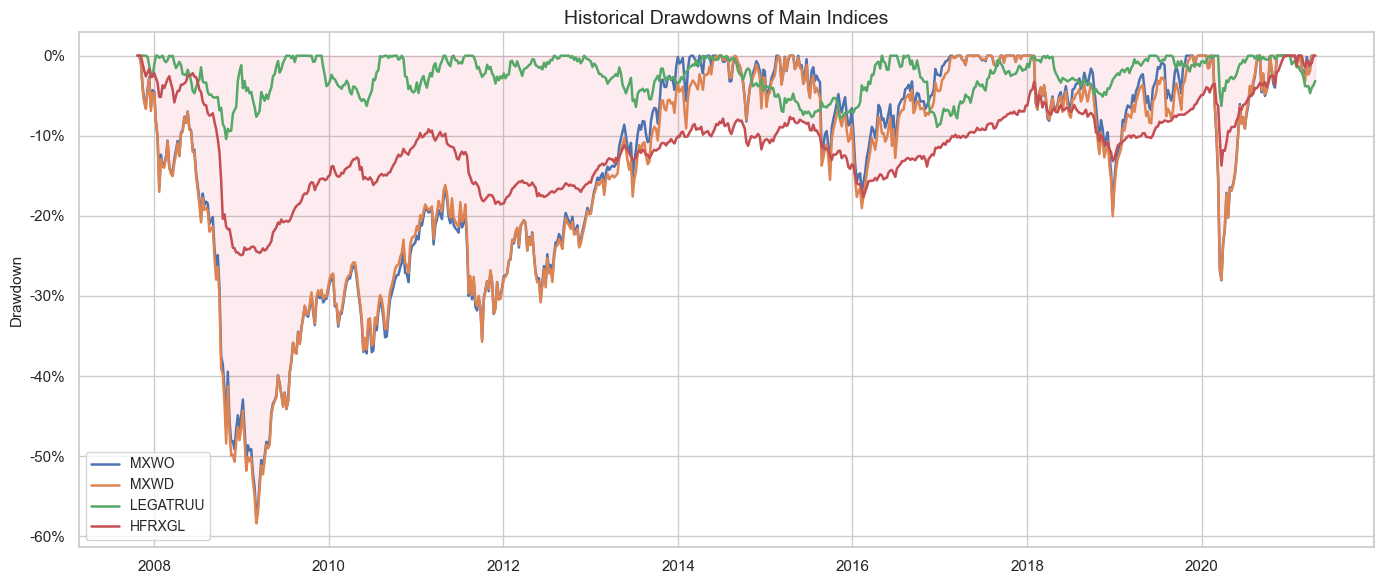

In [5]:
def drawdown_from_prices(price_df):
    wealth = price_df / price_df.iloc[0]
    return wealth / wealth.cummax() - 1

dd_indices = drawdown_from_prices(data[index_cols])

fig, ax = plt.subplots(figsize=(14, 6))
for col in index_cols:
    ax.plot(dd_indices.index, dd_indices[col], label=col, linewidth=1.8)
ax.fill_between(dd_indices.index, dd_indices.min(axis=1), 0, alpha=0.08, color="crimson")
ax.set_title("Historical Drawdowns of Main Indices")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Weekly Returns and Descriptive Statistics

Replication models work on returns rather than price levels. We therefore inspect annualized return, annualized volatility, Sharpe ratio, skewness, kurtosis, best/worst week, and maximum drawdown. Negative skewness and high kurtosis are important because they reveal downside tail risk.


In [6]:
returns = data.pct_change().dropna()

def max_drawdown_from_returns(r):
    wealth = (1 + r).cumprod()
    return (wealth / wealth.cummax() - 1).min()

def perf_stats(ret_df):
    out = pd.DataFrame(index=ret_df.columns)
    out["Ann. Return"] = ret_df.mean() * ANNUAL_FACTOR
    out["Ann. Volatility"] = ret_df.std() * np.sqrt(ANNUAL_FACTOR)
    out["Sharpe (rf=0)"] = out["Ann. Return"] / out["Ann. Volatility"]
    out["Skewness"] = ret_df.skew()
    out["Excess Kurtosis"] = ret_df.kurtosis()
    out["Best Week"] = ret_df.max()
    out["Worst Week"] = ret_df.min()
    out["Max Drawdown"] = ret_df.apply(max_drawdown_from_returns)
    return out

stats_indices = perf_stats(returns[index_cols])
stats_futures = perf_stats(returns[futures_cols])

display(stats_indices.style.format("{:.2%}", subset=["Ann. Return", "Ann. Volatility", "Best Week", "Worst Week", "Max Drawdown"]).format("{:.2f}", subset=["Sharpe (rf=0)", "Skewness", "Excess Kurtosis"]))
display(stats_futures.style.format("{:.2%}", subset=["Ann. Return", "Ann. Volatility", "Best Week", "Worst Week", "Max Drawdown"]).format("{:.2f}", subset=["Sharpe (rf=0)", "Skewness", "Excess Kurtosis"]))


,Ann. Return,Ann. Volatility,Sharpe (rf=0),Skewness,Excess Kurtosis,Best Week,Worst Week,Max Drawdown
MXWO,5.90%,17.52%,0.34,-0.68,4.36,12.94%,-13.60%,-57.61%
MXWD,5.51%,17.78%,0.31,-0.64,4.66,13.90%,-13.68%,-58.39%
LEGATRUU,3.37%,5.34%,0.63,-0.33,4.12,3.54%,-4.68%,-10.41%
HFRXGL,0.50%,4.78%,0.10,-2.30,13.70,2.23%,-5.71%,-24.91%


,Ann. Return,Ann. Volatility,Sharpe (rf=0),Skewness,Excess Kurtosis,Best Week,Worst Week,Max Drawdown
RX1,3.20%,6.14%,0.52,-0.52,1.61,2.79%,-3.19%,-10.39%
TY1,1.50%,5.63%,0.27,-0.41,3.09,3.37%,-4.27%,-12.90%
GC1,7.85%,17.72%,0.44,0.05,3.47,14.00%,-12.57%,-43.18%
CO1,6.51%,40.68%,0.16,1.07,16.38,51.37%,-34.70%,-86.26%
ES1,8.83%,17.01%,0.52,-1.04,5.17,8.76%,-13.96%,-55.11%
VG1,1.49%,21.70%,0.07,-0.09,3.60,18.36%,-13.59%,-58.15%
NQ1,15.46%,19.43%,0.80,-0.94,3.92,8.49%,-16.70%,-52.00%
LLL1,0.53%,18.10%,0.03,-0.57,25.94,20.65%,-24.22%,-64.87%
TP1,4.10%,22.57%,0.18,-0.68,5.15,15.31%,-18.10%,-56.29%
DU1,0.60%,1.13%,0.54,-0.24,5.20,0.69%,-0.85%,-2.77%


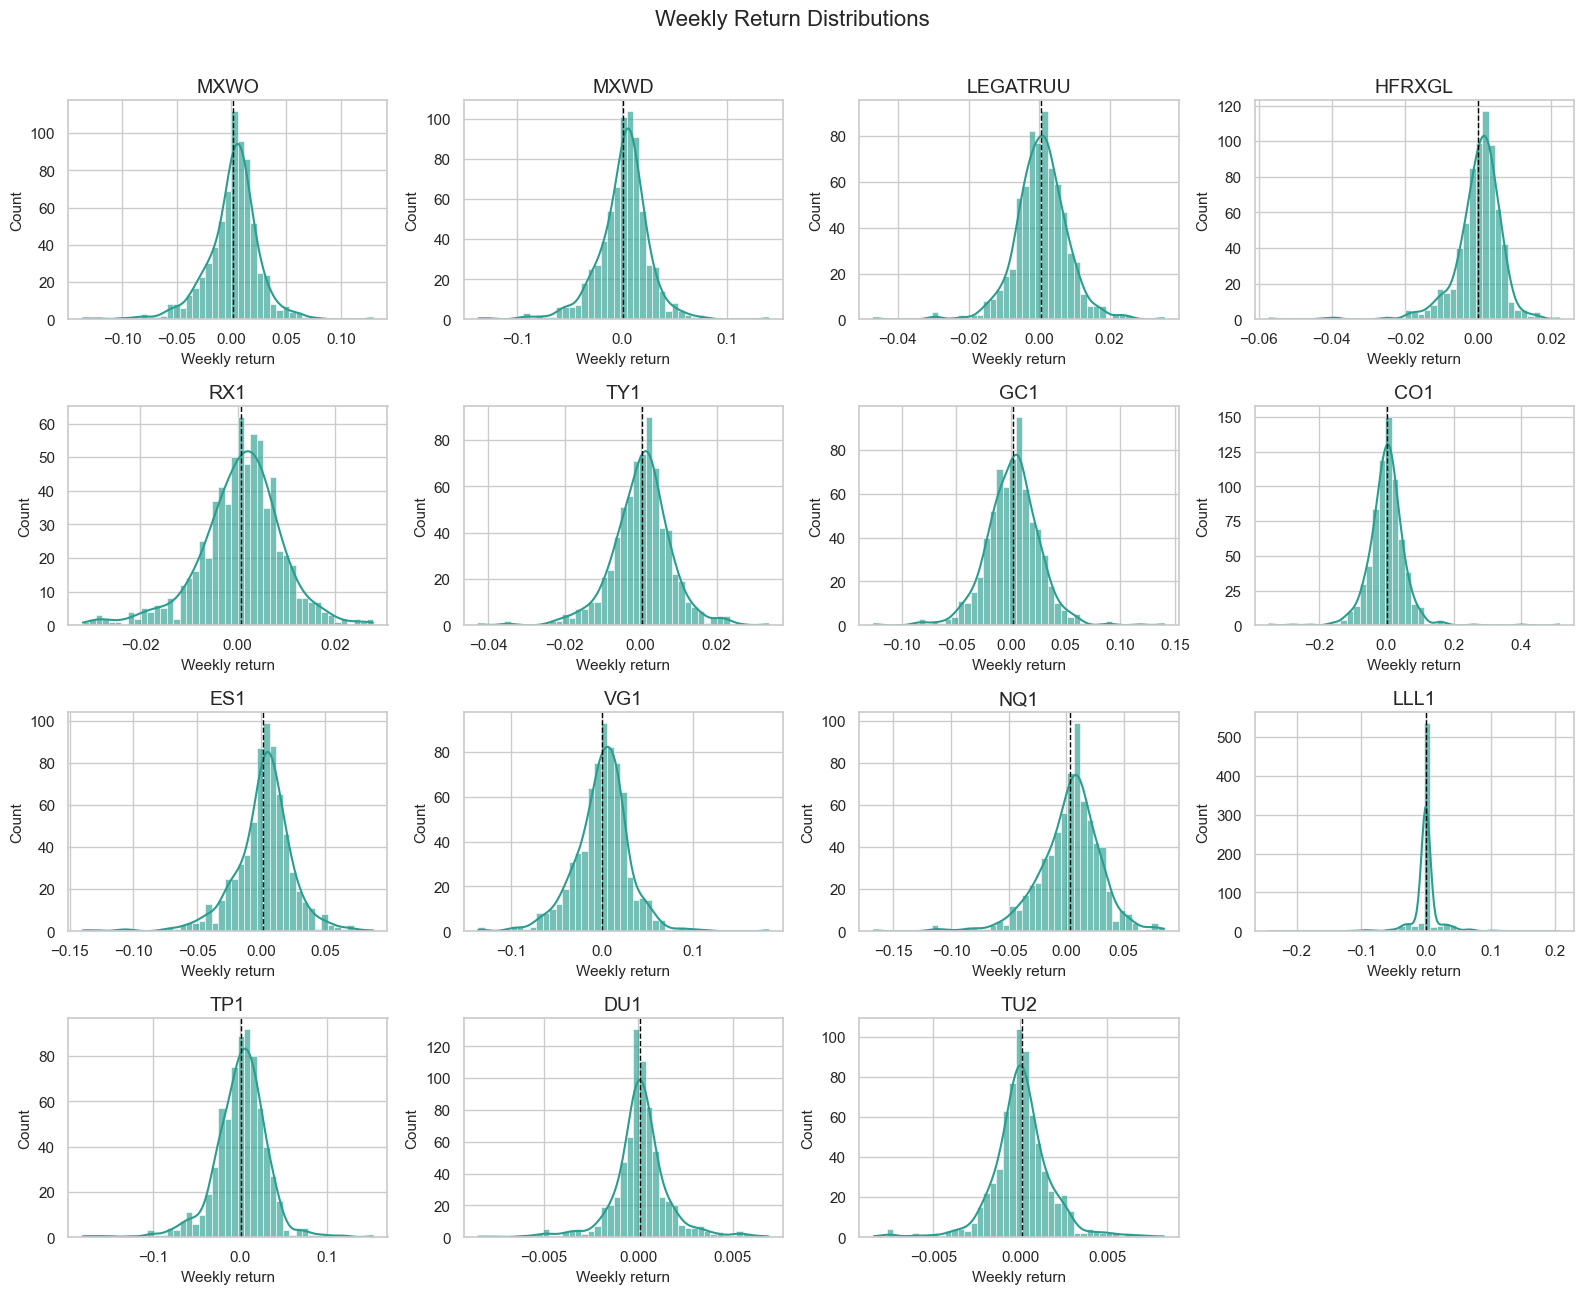

In [7]:
plot_cols = index_cols + futures_cols
n_cols = 4
n_rows = int(np.ceil(len(plot_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    sns.histplot(returns[col], bins=45, kde=True, ax=ax, color="#2A9D8F", alpha=0.65)
    ax.axvline(returns[col].mean(), color="black", linewidth=1, linestyle="--")
    ax.set_title(col)
    ax.set_xlabel("Weekly return")

for ax in axes[len(plot_cols):]:
    ax.axis("off")

plt.suptitle("Weekly Return Distributions", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()


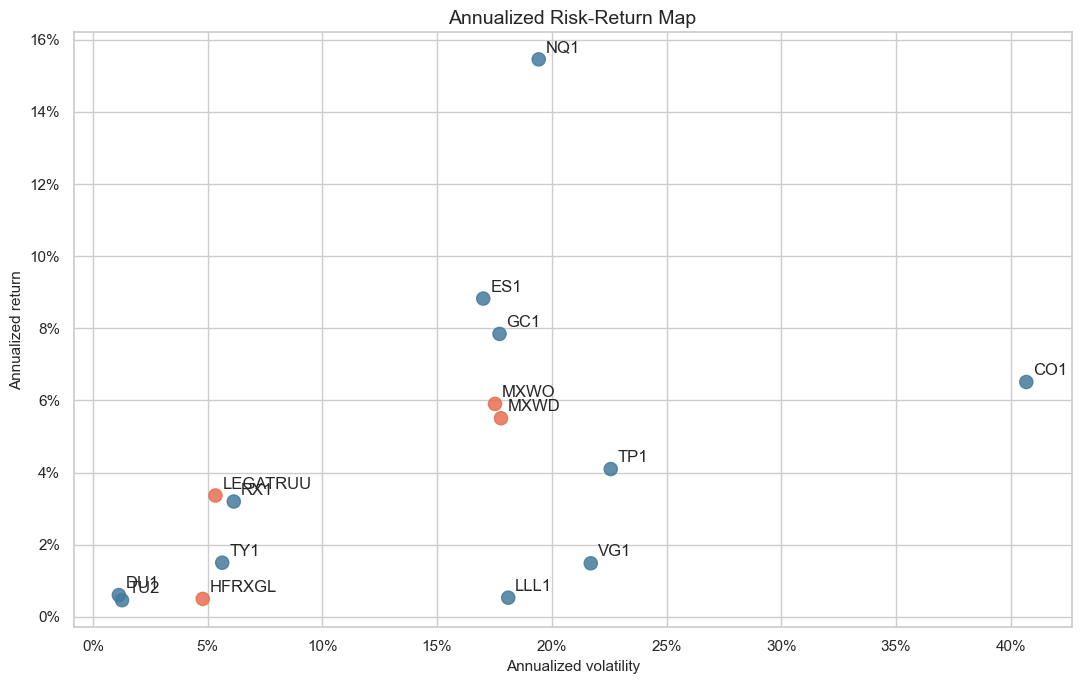

In [8]:
stats_all = perf_stats(returns[plot_cols])

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    stats_all["Ann. Volatility"],
    stats_all["Ann. Return"],
    s=90,
    c=np.where(stats_all.index.isin(index_cols), "#E76F51", "#457B9D"),
    alpha=0.85,
)

for name, row in stats_all.iterrows():
    ax.annotate(name, (row["Ann. Volatility"], row["Ann. Return"]), xytext=(5, 5), textcoords="offset points")

ax.set_title("Annualized Risk-Return Map")
ax.set_xlabel("Annualized volatility")
ax.set_ylabel("Annualized return")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()


## 5b. Normality Tests and Return Autocorrelation

Two additional diagnostics complement the descriptive statistics above:

- **Jarque-Bera test**: formally checks whether the return distribution is Gaussian. Rejection confirms fat tails and asymmetry, which means that Gaussian risk measures (e.g. parametric VaR) will underestimate downside risk.
- **ACF/PACF and Ljung-Box test**: checks whether past returns carry predictive information. Significant autocorrelation would violate the i.i.d. assumption of standard regression models and would suggest the need for time-series-aware estimators.

Both tests are run on the four main indices and on the Monster Index.

In [9]:
import scipy.stats as scipy_stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

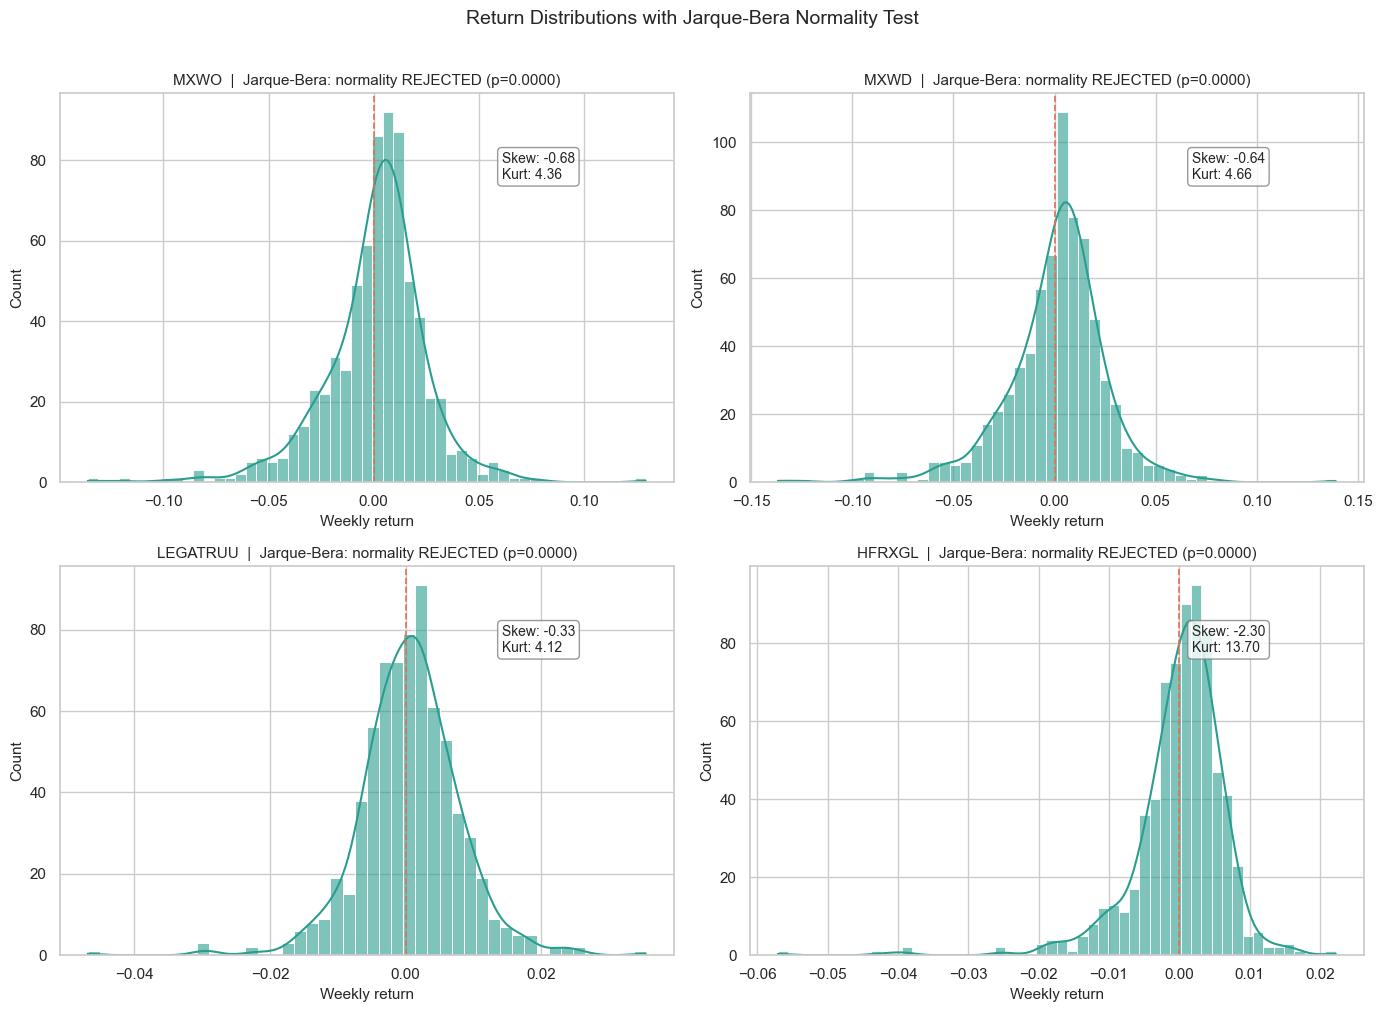

,JB Statistic,p-value,Normality H0
Instrument,,,
MXWO,601.22,0.0000,Rejected
MXWD,674.61,0.0000,Rejected
LEGATRUU,501.10,0.0000,Rejected
HFRXGL,6041.57,0.0000,Rejected


In [10]:
# Jarque-Bera normality test on indices + Monster Index
# (Monster_Index is already in returns after section 6 construction,
#  but here we run on the four base indices for a self-contained diagnostic)
test_cols = index_cols  # ["MXWO", "MXWD", "LEGATRUU", "HFRXGL"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(test_cols):
    r = returns[col].dropna()
    sns.histplot(r, kde=True, ax=axes[i], color="#2A9D8F", alpha=0.60)
    axes[i].axvline(x=0, color="#E76F51", linestyle="--", linewidth=1.2)
    jb_stat, jb_pval = scipy_stats.jarque_bera(r)
    verdict = "REJECTED" if jb_pval < 0.05 else "not rejected"
    axes[i].set_title(
        f"{col}  |  Jarque-Bera: normality {verdict} (p={jb_pval:.4f})",
        fontsize=11
    )
    axes[i].set_xlabel("Weekly return")
    axes[i].annotate(
        f"Skew: {r.skew():.2f}\nKurt: {r.kurtosis():.2f}",
        xy=(0.72, 0.78), xycoords="axes fraction",
        bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8),
        fontsize=10
    )

plt.suptitle("Return Distributions with Jarque-Bera Normality Test", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
jb_rows = []
for col in test_cols:
    r = returns[col].dropna()
    stat, pval = scipy_stats.jarque_bera(r)
    jb_rows.append({"Instrument": col, "JB Statistic": stat, "p-value": pval,
                    "Normality H0": "Rejected" if pval < 0.05 else "Not rejected"})
display(pd.DataFrame(jb_rows).set_index("Instrument").style.format({"JB Statistic": "{:.2f}", "p-value": "{:.4f}"}))

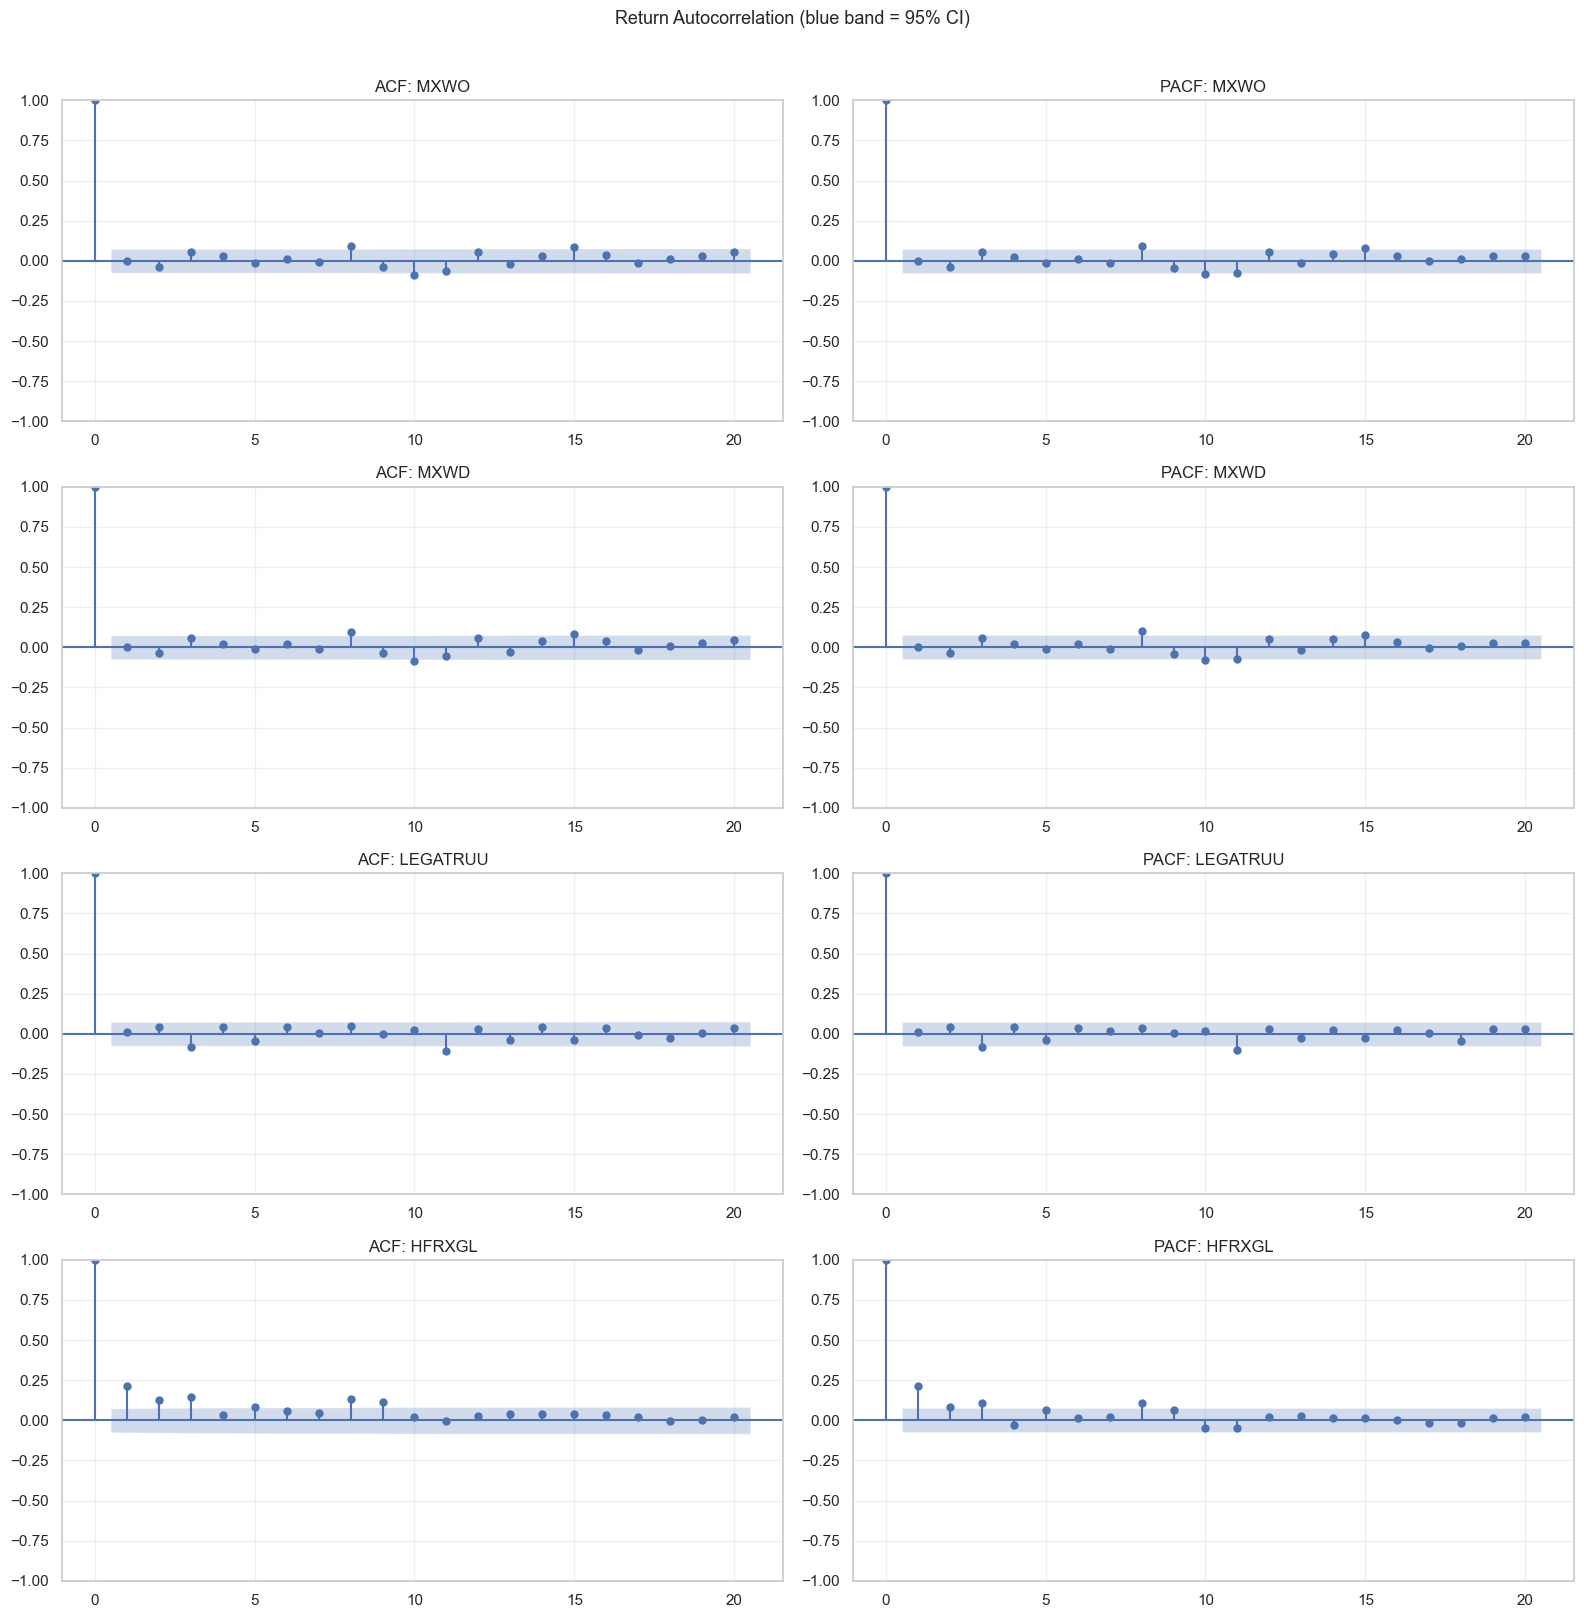

Ljung-Box test (H0: no autocorrelation)



In [11]:
# ACF / PACF plots + Ljung-Box test (H0: no autocorrelation up to lag k)
max_lags = 20
fig, axes = plt.subplots(len(test_cols), 2, figsize=(16, 4 * len(test_cols)))

for i, col in enumerate(test_cols):
    r = returns[col].dropna()
    plot_acf(r,  lags=max_lags, ax=axes[i, 0], alpha=0.05)
    axes[i, 0].set_title(f"ACF: {col}", fontsize=12)
    axes[i, 0].grid(True, alpha=0.3)
    plot_pacf(r, lags=max_lags, ax=axes[i, 1], alpha=0.05)
    axes[i, 1].set_title(f"PACF: {col}", fontsize=12)
    axes[i, 1].grid(True, alpha=0.3)

plt.suptitle("Return Autocorrelation (blue band = 95% CI)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Ljung-Box summary table
print("Ljung-Box test (H0: no autocorrelation)\n")
lb_rows = []
for col in test_cols:
    r = returns[col].dropna()
    lb = acorr_ljungbox(r, lags=[5, 10, 20])
    for lag, row in zip([5, 10, 20], lb.itertuples()):
        lb_rows.append({
            "Instrument": col,
            "Lag": lag,
            "LB Statistic": row.lb_stat,
            "p-value": row.lb_pvalue,
            "Autocorrelation": "Present" if row.lb_pvalue < 0.05 else "None"
        })

lb_df = pd.DataFrame(lb_rows).set_index(["Instrument", "Lag"])
display(lb_df.style.format({"LB Statistic": "{:.2f}", "p-value": "{:.4f}"}))

## 7. Monster Index Construction

The project target is built as a weighted combination of three return streams:

- 50% `HFRXGL`, representing hedge fund / alternative exposure;
- 25% `MXWO`, representing global equity beta;
- 25% `LEGATRUU`, representing global bond exposure.

This construction is economically meaningful because it blends growth, fixed-income diversification, and alternative strategies. It is also difficult to replicate: the hedge fund component can change exposures over time and is not just a static beta portfolio.


In [12]:
target_weights = {"HFRXGL": 0.50, "MXWO": 0.25, "LEGATRUU": 0.25}

returns["Monster_Index"] = sum(returns[col] * weight for col, weight in target_weights.items())
monster_wealth = (1 + returns["Monster_Index"]).cumprod()
monster_base100 = monster_wealth / monster_wealth.iloc[0] * 100

target_comparison = perf_stats(returns[["Monster_Index", "HFRXGL", "MXWO", "LEGATRUU", "MXWD"]])
display(target_comparison.style.format("{:.2%}", subset=["Ann. Return", "Ann. Volatility", "Best Week", "Worst Week", "Max Drawdown"]).format("{:.2f}", subset=["Sharpe (rf=0)", "Skewness", "Excess Kurtosis"]))


,Ann. Return,Ann. Volatility,Sharpe (rf=0),Skewness,Excess Kurtosis,Best Week,Worst Week,Max Drawdown
Monster_Index,2.57%,6.33%,0.41,-1.35,7.64,3.38%,-6.69%,-29.01%
HFRXGL,0.50%,4.78%,0.10,-2.30,13.70,2.23%,-5.71%,-24.91%
MXWO,5.90%,17.52%,0.34,-0.68,4.36,12.94%,-13.60%,-57.61%
LEGATRUU,3.37%,5.34%,0.63,-0.33,4.12,3.54%,-4.68%,-10.41%
MXWD,5.51%,17.78%,0.31,-0.64,4.66,13.90%,-13.68%,-58.39%


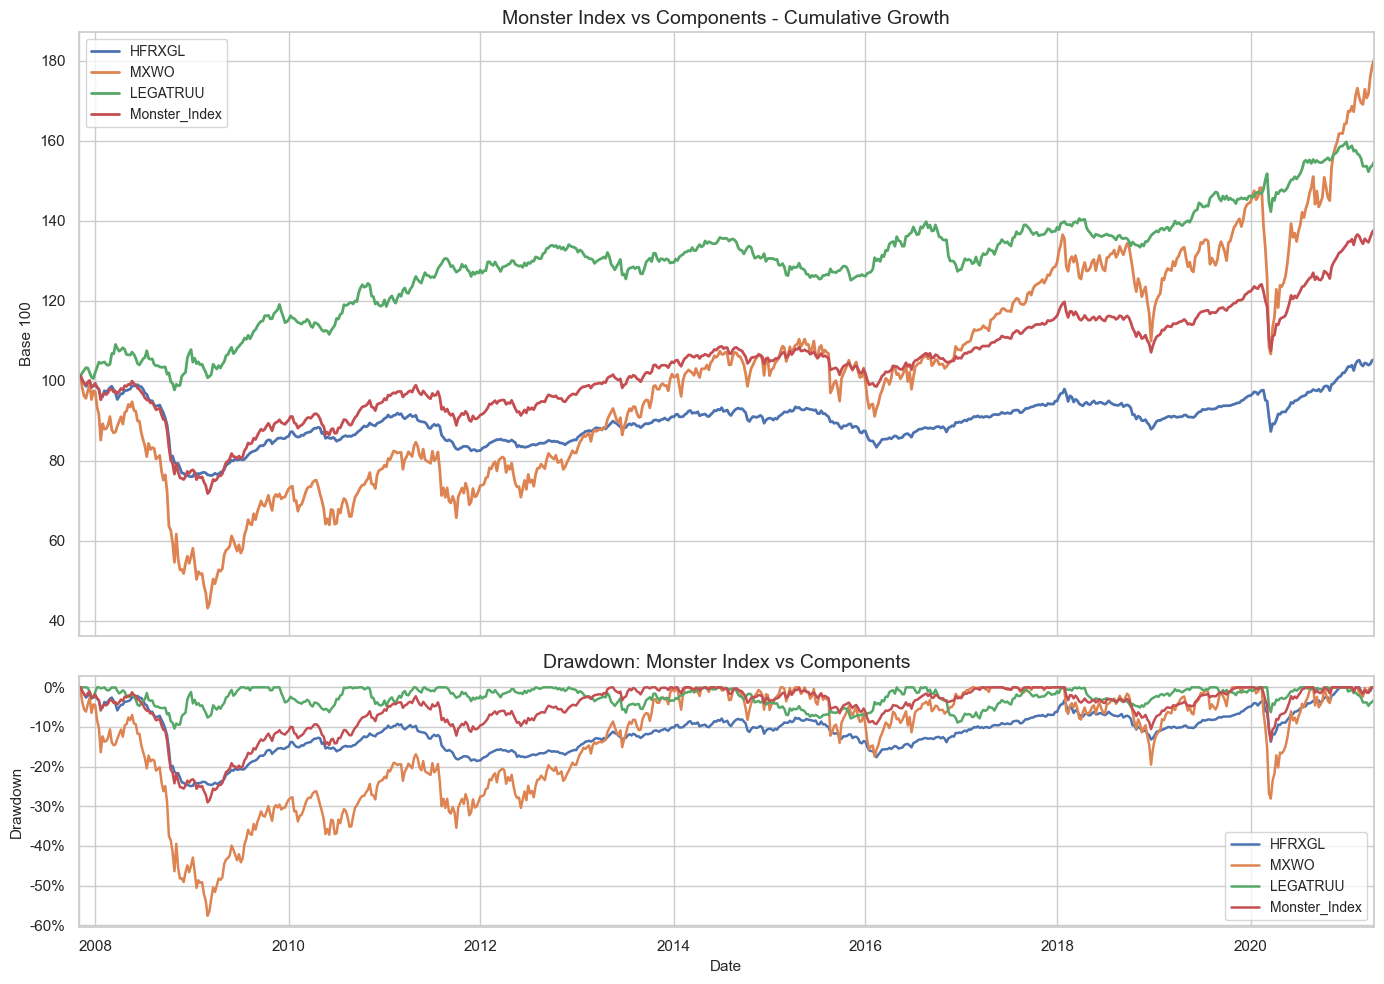

In [13]:
components_base100 = (1 + returns[["HFRXGL", "MXWO", "LEGATRUU", "Monster_Index"]]).cumprod() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={"height_ratios": [2.4, 1]})
components_base100.plot(ax=axes[0], linewidth=2)
axes[0].set_title("Monster Index vs Components - Cumulative Growth")
axes[0].set_ylabel("Base 100")
axes[0].legend()

target_dd = drawdown_from_prices(components_base100)
target_dd.plot(ax=axes[1], linewidth=1.8)
axes[1].set_title("Drawdown: Monster Index vs Components")
axes[1].set_ylabel("Drawdown")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[1].legend()
plt.tight_layout()
plt.show()


## 8. Static Correlations

Static correlation is the first diagnostic for identifying which futures are related to the target. At the same time, high correlation among futures points to **multicollinearity**: several instruments may contain similar information, making unconstrained OLS weights unstable and motivating Ridge/Lasso/Elastic Net models.


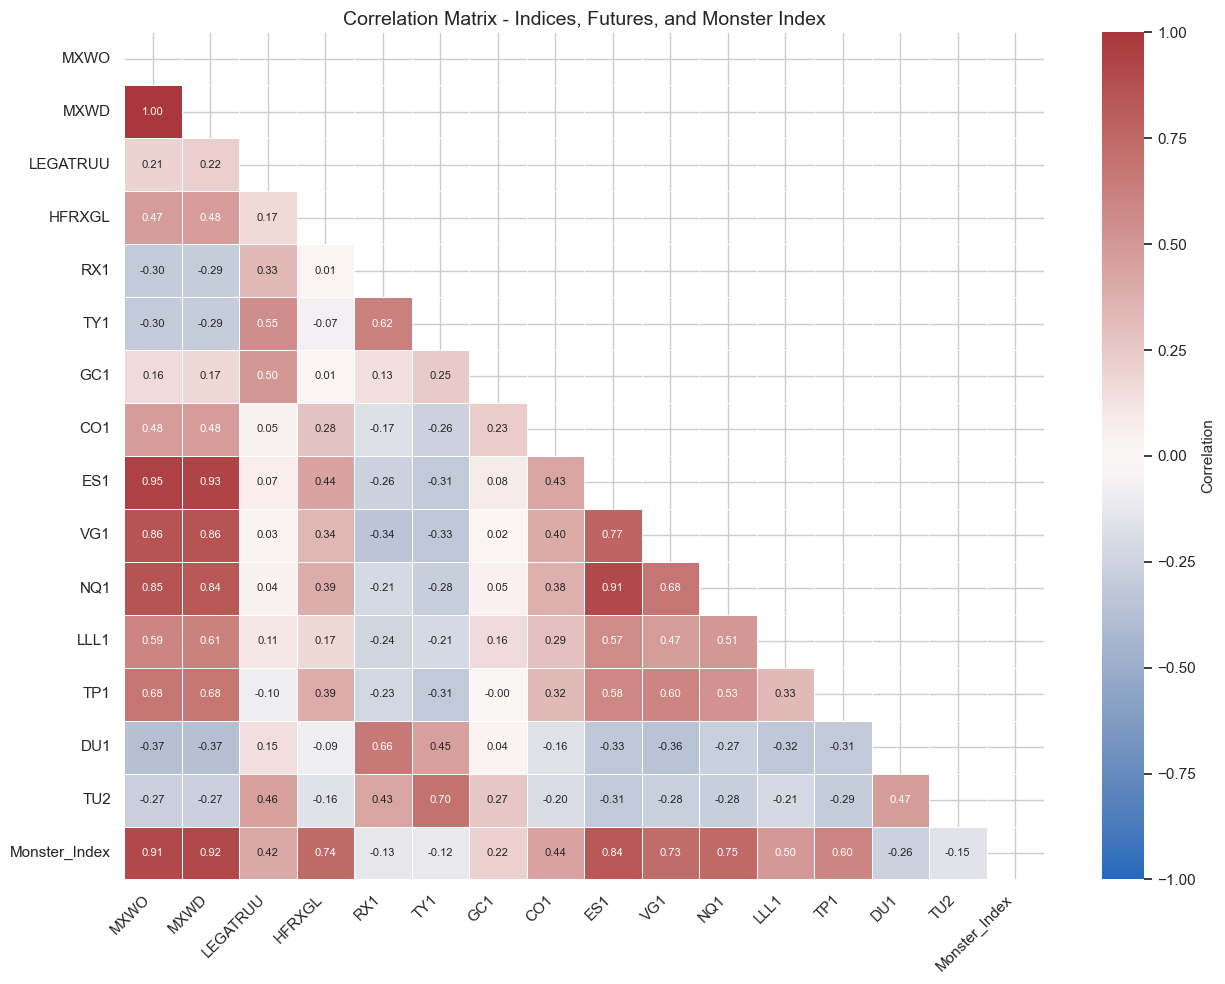

In [14]:
corr_all = returns[index_cols + futures_cols + ["Monster_Index"]].corr()

mask = np.triu(np.ones_like(corr_all, dtype=bool))
plt.figure(figsize=(13, 10))
sns.heatmap(
    corr_all,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 8},
    cbar_kws={"label": "Correlation"},
)
plt.title("Correlation Matrix - Indices, Futures, and Monster Index")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


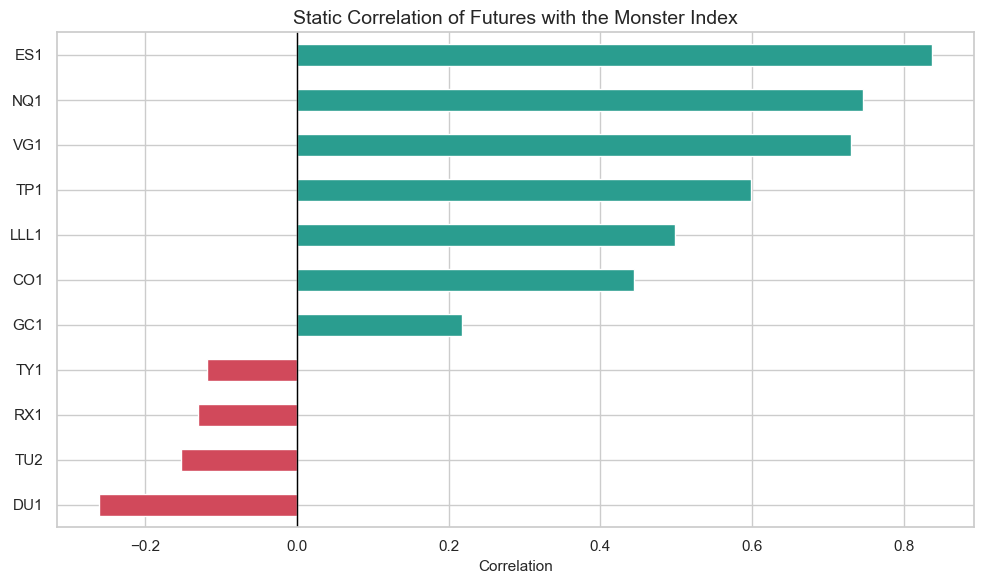

,Correlation with Monster_Index
DU1,-0.2617
TU2,-0.1528
RX1,-0.1307
TY1,-0.1191
GC1,0.2183
CO1,0.4448
LLL1,0.4987
TP1,0.5988
VG1,0.7306
NQ1,0.7469


In [15]:
corr_target = returns[futures_cols].corrwith(returns["Monster_Index"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#D1495B" if x < 0 else "#2A9D8F" for x in corr_target]
corr_target.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Static Correlation of Futures with the Monster Index")
ax.set_xlabel("Correlation")
plt.tight_layout()
plt.show()

display(corr_target.to_frame("Correlation with Monster_Index"))


### Economic Interpretation of the Correlations

The correlations naturally cluster by economic factor:

- equity futures (`ES1`, `NQ1`, `VG1`, `TP1`, `LLL1`) share exposure to the global business cycle, corporate earnings, and market risk appetite;
- bond futures (`TY1`, `TU2`, `RX1`, `DU1`) are driven by duration, expected inflation, and central bank policy;
- gold and oil are more idiosyncratic: `GC1` can behave as a diversifier or safe-haven asset, while `CO1` is more cyclical and exposed to real-economy shocks.

A robust replica should not simply pick the most correlated future. It should also control redundancy, stability, and concentration risk.


## 9. Rolling Correlations and Time Variation

A full-sample correlation can hide regime shifts. We therefore inspect 52-week rolling correlations between the Monster Index and the main futures. If relationships move substantially through time, a fixed-weight model is economically fragile.


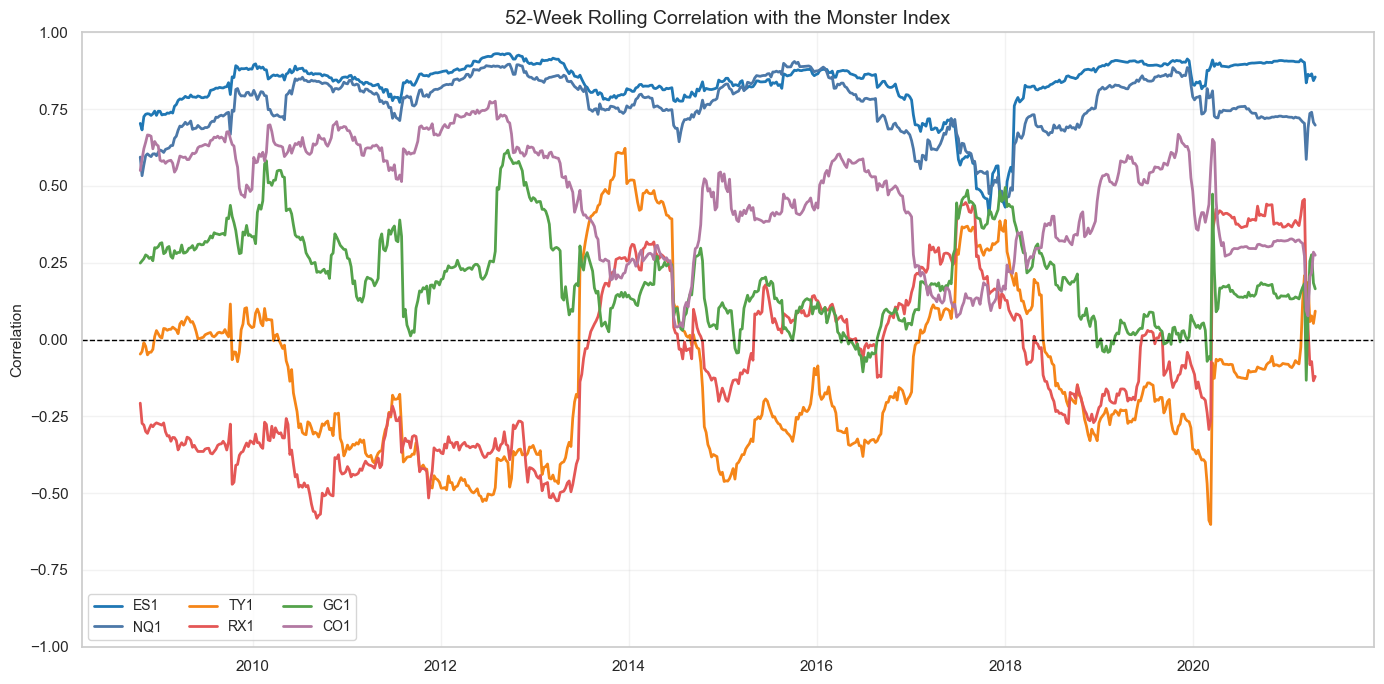

In [16]:
selected_futures = ["ES1", "NQ1", "TY1", "RX1", "GC1", "CO1"]
rolling_corr = pd.DataFrame(index=returns.index)
for col in selected_futures:
    rolling_corr[col] = returns[col].rolling(52).corr(returns["Monster_Index"])

fig, ax = plt.subplots(figsize=(14, 7))
palette = {
    "ES1": "#1f77b4",
    "NQ1": "#4C78A8",
    "TY1": "#F58518",
    "RX1": "#E45756",
    "GC1": "#54A24B",
    "CO1": "#B279A2",
}
for col in selected_futures:
    ax.plot(rolling_corr.index, rolling_corr[col], label=col, linewidth=2, color=palette[col])

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("52-Week Rolling Correlation with the Monster Index")
ax.set_ylabel("Correlation")
ax.set_ylim(-1, 1)
ax.legend(ncol=3, frameon=True)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


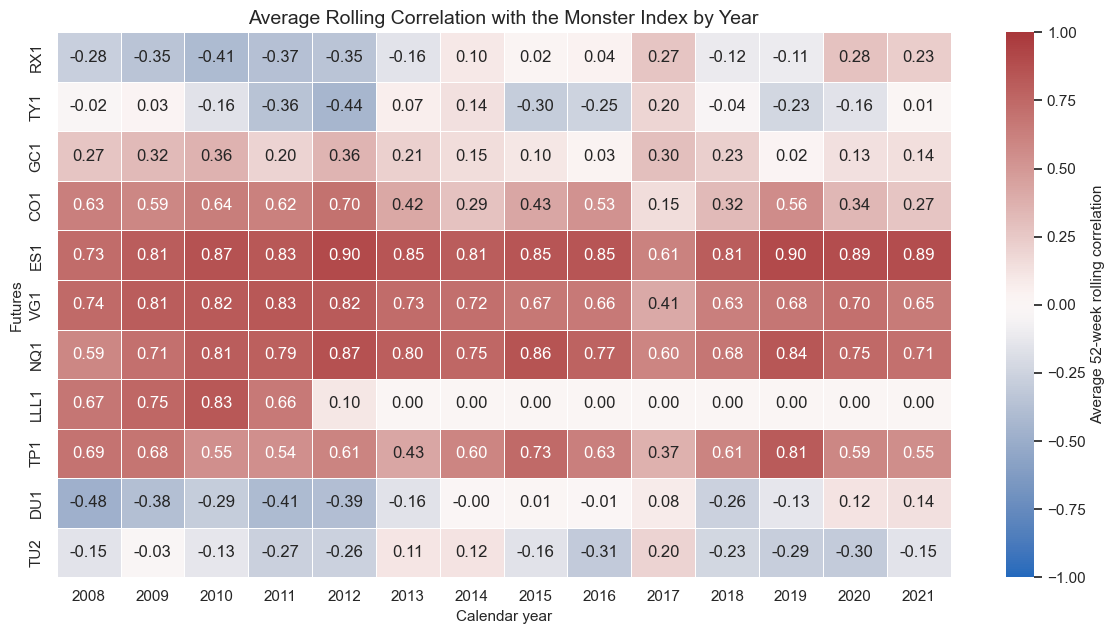

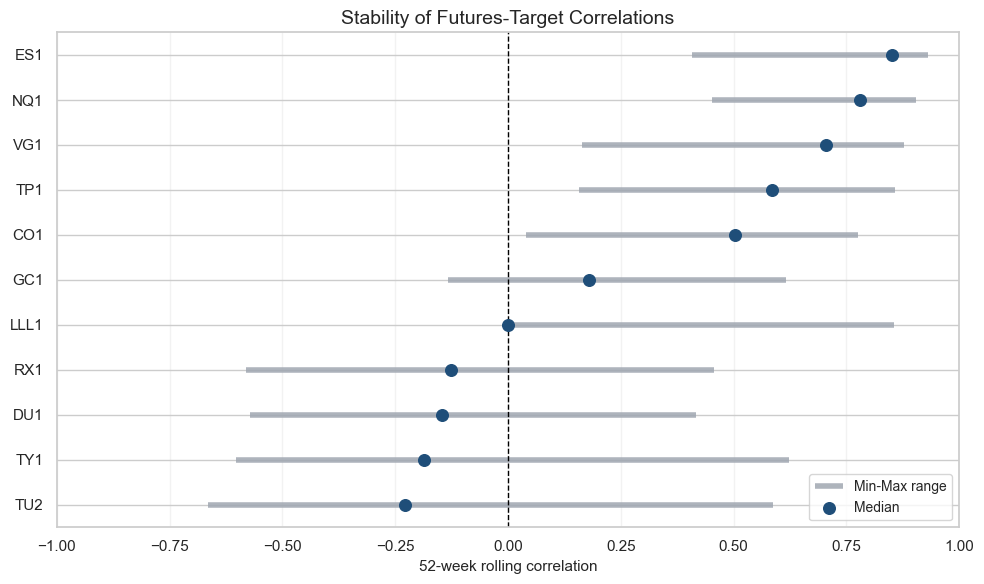

,Median,Min,Max
TU2,-0.23,-0.66,0.59
TY1,-0.19,-0.60,0.62
DU1,-0.15,-0.57,0.42
RX1,-0.13,-0.58,0.46
LLL1,0.00,0.00,0.85
GC1,0.18,-0.13,0.62
CO1,0.50,0.04,0.78
TP1,0.59,0.16,0.86
VG1,0.71,0.16,0.88
NQ1,0.78,0.45,0.91


In [17]:
rolling_corr_all = pd.DataFrame(index=returns.index)
for col in futures_cols:
    rolling_corr_all[col] = returns[col].rolling(52).corr(returns["Monster_Index"])

rolling_corr_clean = rolling_corr_all.dropna()

# A dense date-by-date heatmap is hard to interpret. Aggregating by calendar year
# keeps the regime information while making the chart readable.
annual_corr = rolling_corr_clean.groupby(rolling_corr_clean.index.year).mean().T

plt.figure(figsize=(12, 6.5))
sns.heatmap(
    annual_corr,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Average 52-week rolling correlation"},
)
plt.title("Average Rolling Correlation with the Monster Index by Year")
plt.xlabel("Calendar year")
plt.ylabel("Futures")
plt.tight_layout()
plt.show()

summary_corr = pd.DataFrame({
    "Median": rolling_corr_clean.median(),
    "Min": rolling_corr_clean.min(),
    "Max": rolling_corr_clean.max(),
}).sort_values("Median")

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(summary_corr))
ax.hlines(
    y=y_pos,
    xmin=summary_corr["Min"],
    xmax=summary_corr["Max"],
    color="#A0A7B1",
    linewidth=4,
    alpha=0.85,
    label="Min-Max range",
)
ax.scatter(summary_corr["Median"], y_pos, color="#1F4E79", s=70, zorder=3, label="Median")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(summary_corr.index)
ax.set_xlim(-1, 1)
ax.set_xlabel("52-week rolling correlation")
ax.set_title("Stability of Futures-Target Correlations")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

display(summary_corr.style.format("{:.2f}"))


## 10. Multicollinearity and the Futures Factor Structure

If several futures are driven by the same economic factors, a simple linear regression can produce unstable weights. We therefore measure:

- the most highly correlated futures pairs;
- the effective number of independent factors using PCA on standardized futures returns.


Correlation  AbsCorrelation
ES1 NQ1        0.9133          0.9133
    VG1        0.7718          0.7718
TY1 TU2        0.6995          0.6995
VG1 NQ1        0.6754          0.6754
RX1 DU1        0.6567          0.6567
    TY1        0.6197          0.6197
VG1 TP1        0.5962          0.5962
ES1 TP1        0.5794          0.5794
    LLL1       0.5693          0.5693
NQ1 TP1        0.5295          0.5295
    LLL1       0.5074          0.5074
VG1 LLL1       0.4706          0.4706
DU1 TU2        0.4699          0.4699
TY1 DU1        0.4546          0.4546
RX1 TU2        0.4339          0.4339

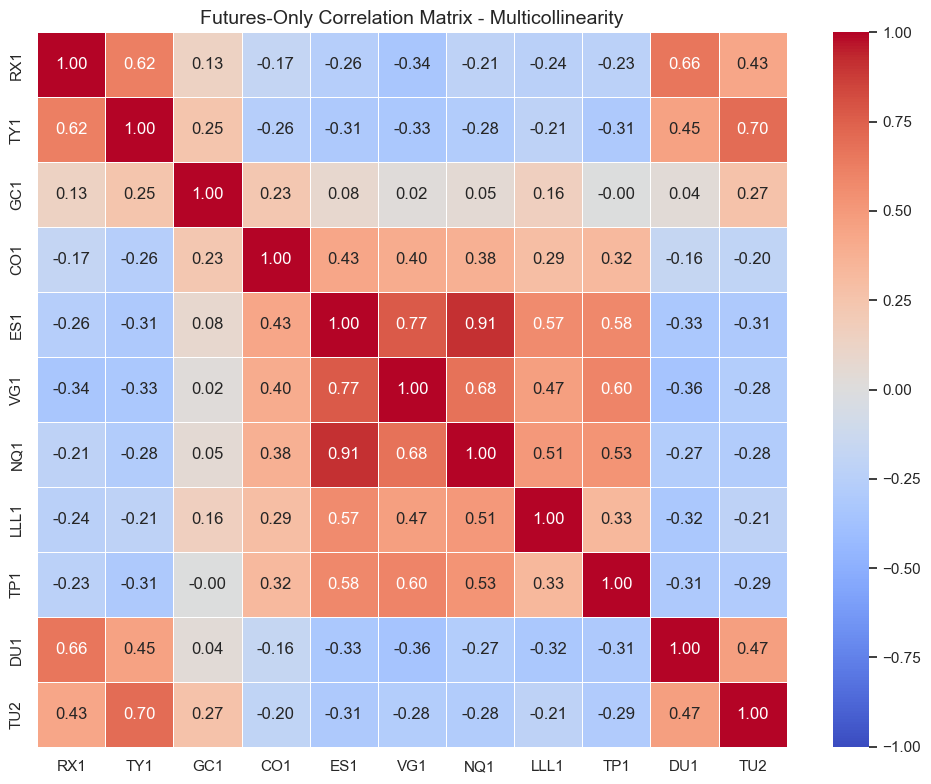

In [18]:
future_corr = returns[futures_cols].corr()
upper = future_corr.where(np.triu(np.ones(future_corr.shape), k=1).astype(bool))
high_pairs = (
    upper.stack()
    .rename("Correlation")
    .to_frame()
    .assign(AbsCorrelation=lambda x: x["Correlation"].abs())
    .sort_values("AbsCorrelation", ascending=False)
)

display(high_pairs.head(15))

plt.figure(figsize=(10, 8))
sns.heatmap(future_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Futures-Only Correlation Matrix - Multicollinearity")
plt.tight_layout()
plt.show()


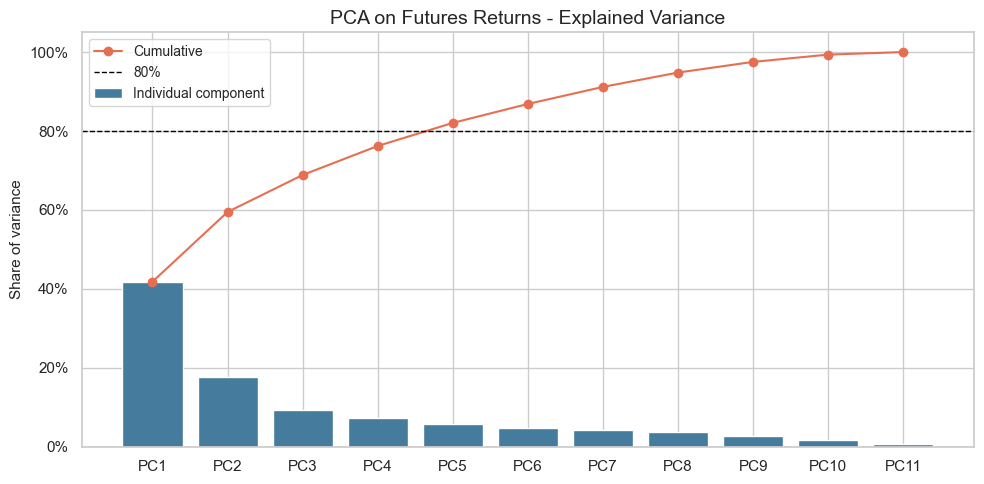

,PC,Explained Variance,Cumulative Explained
0,PC1,0.4181,0.4181
1,PC2,0.1768,0.5949
2,PC3,0.0937,0.6886
3,PC4,0.0735,0.7621
4,PC5,0.0584,0.8206
5,PC6,0.0480,0.8686
6,PC7,0.0432,0.9118
7,PC8,0.0363,0.9481
8,PC9,0.0270,0.9752
9,PC10,0.0184,0.9936


In [19]:
X_std = (returns[futures_cols] - returns[futures_cols].mean()) / returns[futures_cols].std()
u, s, vt = np.linalg.svd(X_std.dropna().values, full_matrices=False)
explained_var = (s ** 2) / np.sum(s ** 2)
pca_table = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_var))],
    "Explained Variance": explained_var,
    "Cumulative Explained": np.cumsum(explained_var),
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pca_table["PC"], pca_table["Explained Variance"], color="#457B9D", label="Individual component")
ax.plot(pca_table["PC"], pca_table["Cumulative Explained"], marker="o", color="#E76F51", label="Cumulative")
ax.axhline(0.80, color="black", linestyle="--", linewidth=1, label="80%")
ax.set_title("PCA on Futures Returns - Explained Variance")
ax.set_ylabel("Share of variance")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend()
plt.tight_layout()
plt.show()

display(pca_table)


### Interpretation

If a small number of principal components explains most of the futures variance, the futures set is more redundant than it initially appears. This is not a dataset flaw; it is a market feature. Risk assets often move together during risk-on/risk-off periods, while government bonds respond to common interest-rate shocks. This supports the use of regularized models and, later, dynamic weights.


## 11. Crisis Period Analysis

A credible replica should be assessed during stress periods, where volatility and correlations can change quickly. This section summarizes the target and its relationship with futures across relevant macro-financial windows.


In [20]:
crisis_periods = {
    "Global Financial Crisis": ("2007-10-23", "2009-03-31"),
    "Euro Debt Crisis": ("2010-04-01", "2012-07-31"),
    "Taper / Rate Normalization": ("2013-05-01", "2015-12-31"),
    "Covid Shock": ("2020-02-15", "2020-04-30"),
    "Covid Recovery": ("2020-05-01", "2021-04-20"),
}

rows = []
for name, (start, end) in crisis_periods.items():
    period_ret = returns.loc[start:end, ["Monster_Index"] + futures_cols]
    if len(period_ret) == 0:
        continue
    stats = perf_stats(period_ret)
    rows.append({
        "Period": name,
        "Start": start,
        "End": end,
        "Weeks": len(period_ret),
        "Target Ann. Return": stats.loc["Monster_Index", "Ann. Return"],
        "Target Ann. Vol": stats.loc["Monster_Index", "Ann. Volatility"],
        "Target Max DD": stats.loc["Monster_Index", "Max Drawdown"],
        "Best Corr Future": period_ret[futures_cols].corrwith(period_ret["Monster_Index"]).idxmax(),
        "Best Corr": period_ret[futures_cols].corrwith(period_ret["Monster_Index"]).max(),
        "Worst Corr Future": period_ret[futures_cols].corrwith(period_ret["Monster_Index"]).idxmin(),
        "Worst Corr": period_ret[futures_cols].corrwith(period_ret["Monster_Index"]).min(),
    })

crisis_table = pd.DataFrame(rows)
display(crisis_table.style.format({
    "Target Ann. Return": "{:.2%}",
    "Target Ann. Vol": "{:.2%}",
    "Target Max DD": "{:.2%}",
    "Best Corr": "{:.2f}",
    "Worst Corr": "{:.2f}",
}))


,Period,Start,End,Weeks,Target Ann. Return,Target Ann. Vol,Target Max DD,Best Corr Future,Best Corr,Worst Corr Future,Worst Corr
0,Global Financial Crisis,2007-10-23,2009-03-31,75,-19.43%,9.83%,-29.01%,ES1,0.77,DU1,-0.45
1,Euro Debt Crisis,2010-04-01,2012-07-31,122,1.67%,6.52%,-10.16%,ES1,0.87,DU1,-0.43
2,Taper / Rate Normalization,2013-05-01,2015-12-31,139,0.90%,4.79%,-6.55%,ES1,0.84,TU2,-0.05
3,Covid Shock,2020-02-15,2020-04-30,11,-31.40%,19.63%,-13.39%,ES1,0.91,TU2,-0.14
4,Covid Recovery,2020-05-01,2021-04-20,51,18.18%,5.18%,-1.69%,ES1,0.85,DU1,-0.17


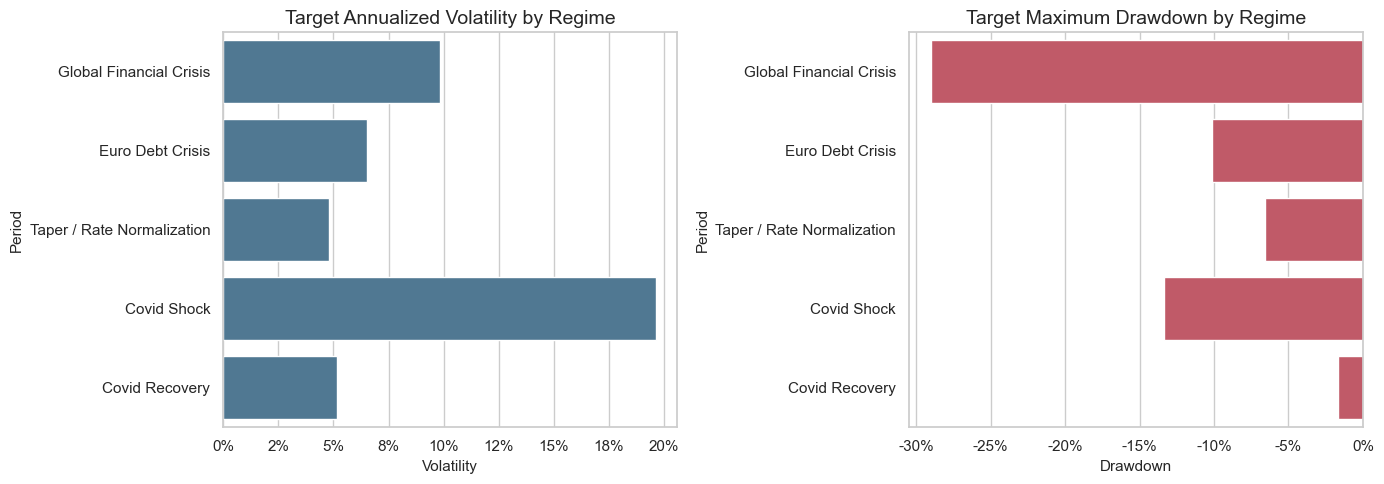

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=crisis_table, x="Target Ann. Vol", y="Period", ax=axes[0], color="#457B9D")
axes[0].set_title("Target Annualized Volatility by Regime")
axes[0].set_xlabel("Volatility")
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

sns.barplot(data=crisis_table, x="Target Max DD", y="Period", ax=axes[1], color="#D1495B")
axes[1].set_title("Target Maximum Drawdown by Regime")
axes[1].set_xlabel("Drawdown")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

plt.tight_layout()
plt.show()


## 12. Volatility Regimes

Another useful diagnostic is to separate high-volatility weeks from normal/low-volatility weeks. During high-volatility regimes, correlations among risky assets often rise, diversification can weaken, and replication becomes more difficult.


,Regime,Weeks,Ann. Return,Ann. Volatility,Max Drawdown,Avg Abs Corr Futures-Target
0,Normal/Low Vol,534,1.93%,4.92%,-15.46%,0.42
1,High Vol,170,4.57%,9.49%,-19.52%,0.44


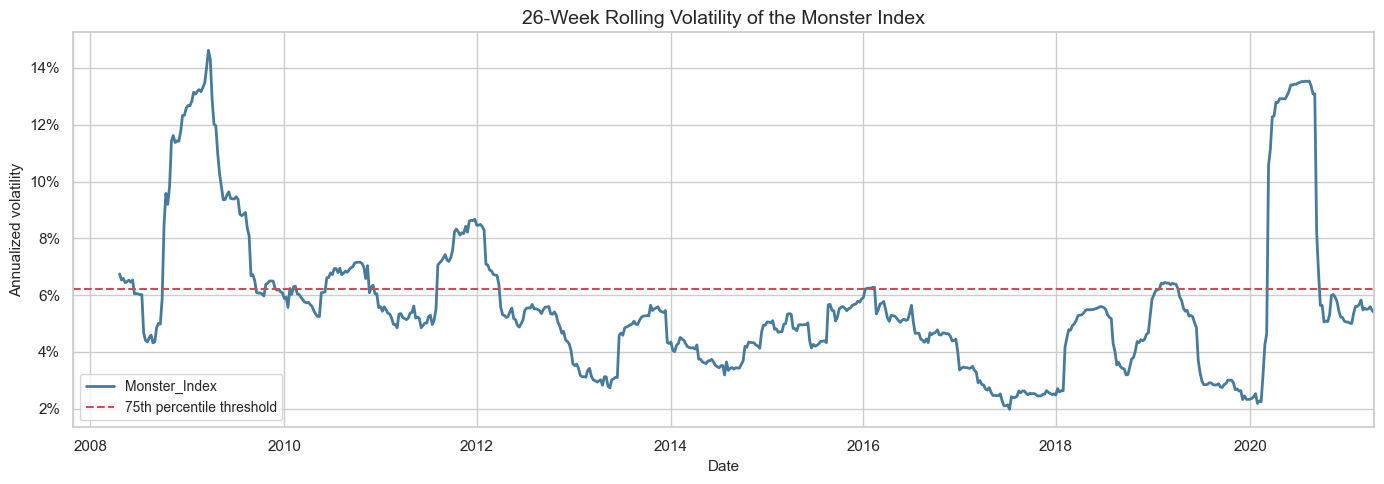

In [22]:
target_vol_26w = returns["Monster_Index"].rolling(26).std() * np.sqrt(ANNUAL_FACTOR)
vol_threshold = target_vol_26w.quantile(0.75)
regime = pd.Series("Normal/Low Vol", index=returns.index)
regime[target_vol_26w > vol_threshold] = "High Vol"

regime_rows = []
for reg in ["Normal/Low Vol", "High Vol"]:
    idx = regime[regime == reg].index
    subset = returns.loc[idx, ["Monster_Index"] + futures_cols].dropna()
    s = perf_stats(subset[["Monster_Index"]]).loc["Monster_Index"]
    regime_rows.append({
        "Regime": reg,
        "Weeks": len(subset),
        "Ann. Return": s["Ann. Return"],
        "Ann. Volatility": s["Ann. Volatility"],
        "Max Drawdown": s["Max Drawdown"],
        "Avg Abs Corr Futures-Target": subset[futures_cols].corrwith(subset["Monster_Index"]).abs().mean(),
    })

regime_table = pd.DataFrame(regime_rows)
display(regime_table.style.format({
    "Ann. Return": "{:.2%}",
    "Ann. Volatility": "{:.2%}",
    "Max Drawdown": "{:.2%}",
    "Avg Abs Corr Futures-Target": "{:.2f}",
}))

fig, ax = plt.subplots(figsize=(14, 5))
target_vol_26w.plot(ax=ax, color="#457B9D", linewidth=2)
ax.axhline(vol_threshold, color="#D1495B", linestyle="--", label="75th percentile threshold")
ax.set_title("26-Week Rolling Volatility of the Monster Index")
ax.set_ylabel("Annualized volatility")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend()
plt.tight_layout()
plt.show()


## 13. EDA Conclusions

The analysis leads to five main conclusions:

1. The dataset is coherent, weekly, and has no missing values, so it is suitable for rolling backtests.
2. The Monster Index combines hedge fund, global equity, and global bond exposures, making it more complex than a pure equity benchmark.
3. Equity and bond futures show clear correlation clusters. This creates multicollinearity and can make unregularized OLS weights unstable.
4. Rolling correlations change materially over time, especially during crises. A fixed-weight replica may work on average but fail in stress regimes.
5. The evidence supports the next modeling step: penalized linear models to stabilize weights, and Kalman filtering to allow time-varying exposures.

This EDA therefore provides a complete empirical foundation for the replication stage: out-of-sample model comparison, tracking error analysis, and interpretation of dynamic weights.
